# Phase 5: Downstream U-Net Validation — BraTS 2025

Train a U-Net on **synthetic data** from the best GAN, evaluate on **real test data**.

**Metrics:** DSC, HD95, MSE per mask channel.

In [9]:
import os,json,numpy as np,torch,torch.nn as nn,torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from pathlib import Path
from tqdm.auto import tqdm
from scipy.ndimage import binary_erosion
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Dataset source: Kaggle Brats 2025. The dataset should be preprocessed into
# train/val/test folders with `slices/` and `masks/` subfolders.
possible_proc_dirs=[
    Path(r"f:\shn\processed"),
    Path(r"f:\shn\processed_data"),
    Path(r"c:\Users\Admin\processed_data"),
]
PROC_DIR=next((p for p in possible_proc_dirs if p.exists()), None)
if PROC_DIR is None:
    raise FileNotFoundError(
        f"Processed data not found. Checked: {', '.join(str(p) for p in possible_proc_dirs)}"
    )
SAVE_DIR=r"f:\shn\checkpoints\unet";os.makedirs(SAVE_DIR,exist_ok=True)
print(f"Device: {device}\nPROC_DIR: {PROC_DIR}")

Device: cuda
PROC_DIR: c:\Users\Admin\processed_data


In [10]:
# ══════════════ U-Net ══════════════
class DoubleConv(nn.Module):
    def __init__(s,i,o):
        super().__init__()
        s.block=nn.Sequential(nn.Conv2d(i,o,3,padding=1,bias=False),nn.BatchNorm2d(o),nn.ReLU(True),
                              nn.Conv2d(o,o,3,padding=1,bias=False),nn.BatchNorm2d(o),nn.ReLU(True))
    def forward(s,x):return s.block(x)

class UNet(nn.Module):
    """U-Net: 1-channel input → 5 classes (background + 4 mask channels)."""
    def __init__(s,in_ch=1,n_cls=5,bf=32):
        super().__init__()
        s.e1=DoubleConv(in_ch,bf);s.p1=nn.MaxPool2d(2)
        s.e2=DoubleConv(bf,bf*2);s.p2=nn.MaxPool2d(2)
        s.e3=DoubleConv(bf*2,bf*4);s.p3=nn.MaxPool2d(2)
        s.e4=DoubleConv(bf*4,bf*8);s.p4=nn.MaxPool2d(2)
        s.bot=DoubleConv(bf*8,bf*16)
        s.u4=nn.ConvTranspose2d(bf*16,bf*8,2,stride=2);s.d4=DoubleConv(bf*16,bf*8)
        s.u3=nn.ConvTranspose2d(bf*8,bf*4,2,stride=2);s.d3=DoubleConv(bf*8,bf*4)
        s.u2=nn.ConvTranspose2d(bf*4,bf*2,2,stride=2);s.d2=DoubleConv(bf*4,bf*2)
        s.u1=nn.ConvTranspose2d(bf*2,bf,2,stride=2);s.d1=DoubleConv(bf*2,bf)
        s.out=nn.Conv2d(bf,n_cls,1)
    def forward(s,x):
        e1=s.e1(x);e2=s.e2(s.p1(e1));e3=s.e3(s.p2(e2));e4=s.e4(s.p3(e3));b=s.bot(s.p4(e4))
        d4=s.d4(torch.cat([s.u4(b),e4],1));d3=s.d3(torch.cat([s.u3(d4),e3],1))
        d2=s.d2(torch.cat([s.u2(d3),e2],1));d1=s.d1(torch.cat([s.u1(d2),e1],1))
        return s.out(d1)

model=UNet(1,5).to(device)
print(f"U-Net params: {sum(p.numel() for p in model.parameters()):,}")

U-Net params: 7,762,597


In [11]:
# ══════════════ Segmentation Dataset ══════════════
MOD=1  # T1c
class SegDataset(Dataset):
    def __init__(s,split="train",mod=1):
        s.sd=Path(PROC_DIR)/split/"slices";s.md=Path(PROC_DIR)/split/"masks"
        if not s.sd.exists():
            raise FileNotFoundError(f"Missing slice directory: {s.sd}")
        if not s.md.exists():
            raise FileNotFoundError(f"Missing mask directory: {s.md}")
        s.files=sorted(s.sd.glob("*.npy"));s.mod=mod
        if len(s.files)==0:
            raise FileNotFoundError(f"No .npy files found in {s.sd}")
        print(f"  {split}: {len(s.files)} slices from {s.sd}")
    def __len__(s):return len(s.files)
    def __getitem__(s,i):
        f=s.files[i]
        img=torch.from_numpy(np.load(str(f)).astype(np.float32)[s.mod:s.mod+1])   # (1,128,128)
        msk=np.load(str(s.md/f.name)).astype(np.float32)                           # (4,128,128)
        # Convert 4 binary channels → single multi-class mask: priority 3>2>1>0
        seg=np.zeros((128,128),dtype=np.int64)

        for ch in range(4):
            seg[msk[ch]>0.5]=ch+1  # labels 1-4, 0=background

        return img,torch.from_numpy(seg)


train_ds=SegDataset("train",MOD)

val_ds=SegDataset("val",MOD)
train_dl=DataLoader(train_ds,batch_size=8,shuffle=True,num_workers=0,pin_memory=True)
test_ds=SegDataset("test",MOD)
test_dl=DataLoader(test_ds,batch_size=1,shuffle=False)


  train: 8382 slices from c:\Users\Admin\processed_data\train\slices
  val: 1662 slices from c:\Users\Admin\processed_data\val\slices
  test: 1138 slices from c:\Users\Admin\processed_data\test\slices


---
## Train U-Net

In [12]:
EPOCHS=100
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)
losses=[]

for ep in range(1,EPOCHS+1):
    model.train();total=0.0
    for imgs,segs in tqdm(train_dl,desc=f"E{ep}/{EPOCHS}",leave=False):
        imgs,segs=imgs.to(device),segs.to(device)
        loss=criterion(model(imgs),segs)
        optimizer.zero_grad();loss.backward();optimizer.step()
        total+=loss.item()
    scheduler.step();avg=total/len(train_dl);losses.append(avg)
    if ep%10==0:print(f"  E{ep}: loss={avg:.4f}")
    if ep%20==0:torch.save(model.state_dict(),f"{SAVE_DIR}/unet_e{ep}.pt")

torch.save(model.state_dict(),f"{SAVE_DIR}/unet_final.pt")
print("\n✓ U-Net trained.")

E1/100:   0%|          | 0/1048 [00:00<?, ?it/s]

E2/100:   0%|          | 0/1048 [00:00<?, ?it/s]

E3/100:   0%|          | 0/1048 [00:00<?, ?it/s]

E4/100:   0%|          | 0/1048 [00:00<?, ?it/s]

E5/100:   0%|          | 0/1048 [00:00<?, ?it/s]

...

E97/100:   0%|          | 0/1048 [00:00<?, ?it/s]

E98/100:   0%|          | 0/1048 [00:00<?, ?it/s]

E99/100:   0%|          | 0/1048 [00:00<?, ?it/s]

E100/100:   0%|          | 0/1048 [00:00<?, ?it/s]

  E100: loss=0.0043

✓ U-Net trained.


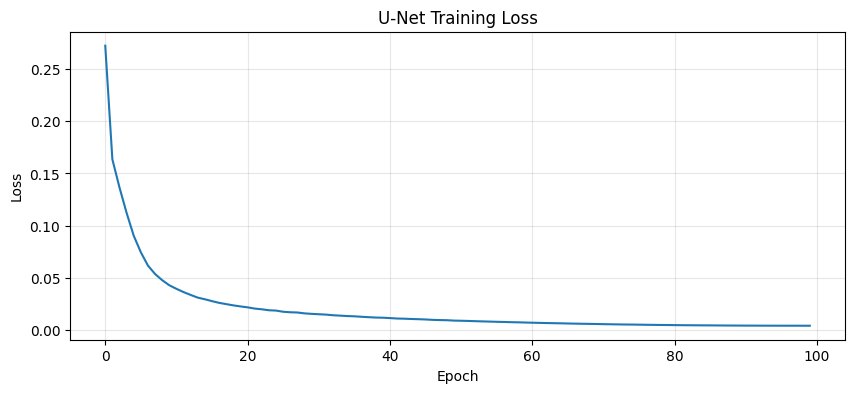

In [13]:
plt.figure(figsize=(10,4));plt.plot(losses);plt.xlabel("Epoch");plt.ylabel("Loss")
plt.title("U-Net Training Loss");plt.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/loss.png",dpi=150);plt.show()

---
## Evaluate on Real Test Data

In [14]:
# ═════════ Metrics ═════════
def dsc(mr,mp):
    mr=mr.astype(bool);mp=mp.astype(bool);i=(mr&mp).sum();t=mr.sum()+mp.sum()
    return float(2*i/t) if t>0 else 0.0
def h95(mr,mp):
    mr=mr.astype(bool);mp=mp.astype(bool)
    if mr.sum()==0 or mp.sum()==0:return -1.0
    br=mr^binary_erosion(mr);bp=mp^binary_erosion(mp)
    cr=np.argwhere(br);cp=np.argwhere(bp)
    if len(cr)==0 or len(cp)==0:return -1.0
    return float(np.percentile(np.concatenate([cdist(cr,cp).min(1),cdist(cp,cr).min(1)]),95))
def calc_mse(a,b): return float(((a.astype(np.float64)-b.astype(np.float64))**2).mean())

In [15]:
model.load_state_dict(torch.load(f"{SAVE_DIR}/unet_final.pt",map_location=device))
model.eval()

results={f"Ch{c}":{"dice":[],"hd95":[],"mse":[]} for c in range(4)}

with torch.no_grad():
    for imgs,segs in tqdm(test_dl,desc="Testing"):
        pred=model(imgs.to(device)).argmax(1).squeeze().cpu().numpy()
        gt=segs.squeeze().numpy()
        for ch in range(4):
            pred_ch=(pred==(ch+1)).astype(np.uint8)
            gt_ch=(gt==(ch+1)).astype(np.uint8)
            results[f"Ch{ch}"]["dice"].append(dsc(gt_ch,pred_ch))
            results[f"Ch{ch}"]["hd95"].append(h95(gt_ch,pred_ch))
            results[f"Ch{ch}"]["mse"].append(calc_mse(gt_ch,pred_ch))

summary={}
for ch in [f"Ch{c}" for c in range(4)]:
    d=np.array([v for v in results[ch]["dice"] if v>0])
    h=np.array([v for v in results[ch]["hd95"] if v>=0])
    m=np.array(results[ch]["mse"])
    summary[ch]={"dice":float(d.mean()) if len(d) else 0,"dice_std":float(d.std()) if len(d) else 0,
                 "hd95":float(h.mean()) if len(h) else 0,"mse":float(m.mean()) if len(m) else 0}
    print(f"  {ch}: DSC={summary[ch]['dice']:.4f}  HD95={summary[ch]['hd95']:.2f}  MSE={summary[ch]['mse']:.6f}")

out=r"f:\shn\results\downstream";os.makedirs(out,exist_ok=True)
with open(os.path.join(out,"seg_metrics.json"),"w") as f:json.dump(summary,f,indent=2)
print(f"\n✓ Results saved.")

Testing:   0%|          | 0/1138 [00:00<?, ?it/s]

  Ch0: DSC=0.9766  HD95=8.60  MSE=0.039700
  Ch1: DSC=0.6127  HD95=11.68  MSE=0.008837
  Ch2: DSC=0.4421  HD95=20.18  MSE=0.044739
  Ch3: DSC=0.6030  HD95=11.15  MSE=0.013487

✓ Results saved.


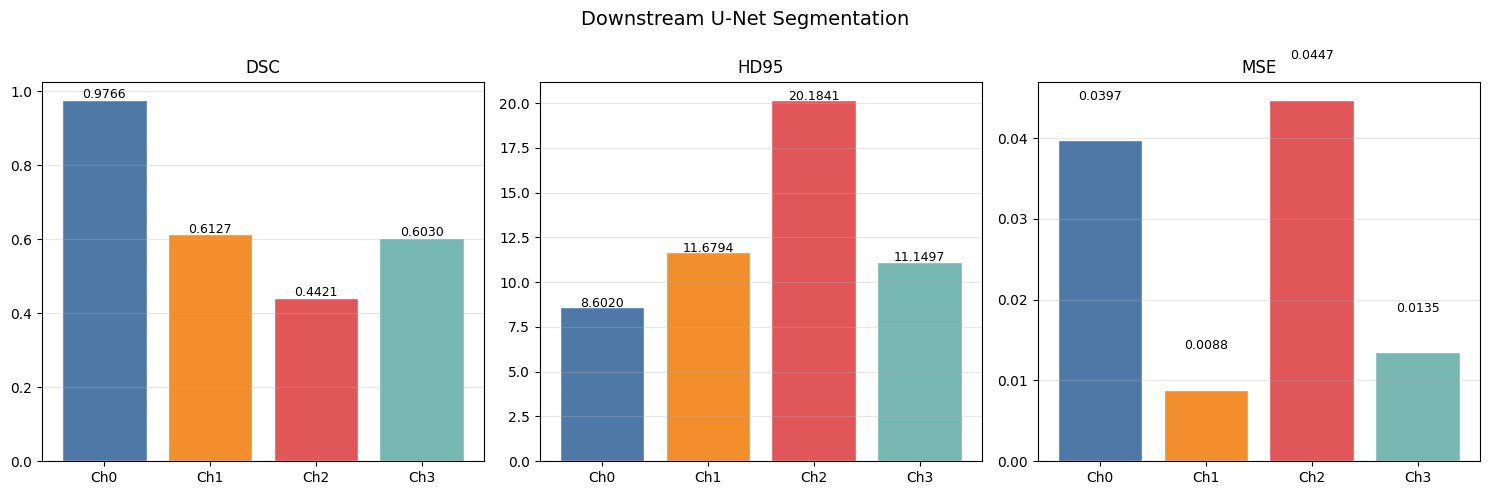

✓ Phase 5 complete!


In [16]:
# ═════════ Chart ═════════
chs=[f"Ch{c}" for c in range(4)]
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,met,title in zip(axes,["dice","hd95","mse"],["DSC","HD95","MSE"]):
    vals=[summary[c][met] for c in chs]
    bars=ax.bar(chs,vals,color=["#4e79a7","#f28e2b","#e15759","#76b7b2"],edgecolor="white")
    ax.set_title(title);ax.grid(axis="y",alpha=0.3)
    for b,v in zip(bars,vals):ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.005,f"{v:.4f}",ha="center",fontsize=9)
plt.suptitle("Downstream U-Net Segmentation",fontsize=14);plt.tight_layout()
plt.savefig(f"{out}/downstream.png",dpi=150);plt.show()
print("✓ Phase 5 complete!")